# Explorando capas convolucionales a través de datos y experimentos

- **Autor**: Carlos David Barrero Velasquez
- **Universidad**: Escuela Colombiana de Ingeniería Julio Garavito
- **Asignatura**: Arquitecturas Empresariales (AREP)
- **Fecha**: Febrero 2026

## Introducción
Este taller explora las **Redes Neuronales Convolucionales** mediante un análisis progresivo del dataset de Pokémon que fue el que escogí apoyado de Kaggle. A través de experimentación controlada y comparación de modelos, entenderás por qué las capas convolucionales son fundamentales para tareas de clasificación de imágenes.


# 1. Dataset Exploration (EDA)

## Exploración de Datos del Dataset de Pokémon

Este análisis explora la estructura, dimensiones y características del dataset de Pokémon para preparar el entrenamiento de redes neuronales convolucionales.

### Objetivos
- Tamaño del dataset y distribución de clases
- Dimensiones y canales de las imágenes
- Ejemplos visuales de muestras por clase
- Identificar necesidades de preprocesamiento

## 1.1 Librerías necesarias

In [51]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter
import warnings

warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)

# Configure visualization
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

## 1.2 Cargar e inspeccionar el dataset

In [52]:
base_path = r'archive'
csv_path = os.path.join(base_path, 'pokemon.csv')
images_dir = os.path.join(base_path, 'images')

pokemon_df = pd.read_csv(csv_path)

print("ESTRUCTURA DEL DATASET")
print(f"Dimensiones: {pokemon_df.shape[0]} muestras × {pokemon_df.shape[1]} columnas")
print(f"Columnas: {pokemon_df.columns.tolist()}")
print(f"\nPrimeras 6 filas:")
print(pokemon_df.head(6).to_string())
print(f"\nTipos de datos (tipo de información en cada columna):")
for col, dtype in pokemon_df.dtypes.items():
    print(f"  {col}: {dtype}")
print(f"\nValores faltantes (celdas vacías por columna):")
for col, missing in pokemon_df.isnull().sum().items():
    print(f"  {col}: {missing} valores faltantes")

ESTRUCTURA DEL DATASET
Dimensiones: 809 muestras × 4 columnas
Columnas: ['Name', 'Type1', 'Type2', 'Evolution']

Primeras 6 filas:
         Name  Type1   Type2   Evolution
0   bulbasaur  Grass  Poison     ivysaur
1     ivysaur  Grass  Poison    venusaur
2    venusaur  Grass  Poison         NaN
3  charmander   Fire     NaN  charmeleon
4  charmeleon   Fire     NaN   charizard
5   charizard   Fire  Flying         NaN

Tipos de datos (tipo de información en cada columna):
  Name: str
  Type1: str
  Type2: str
  Evolution: str

Valores faltantes (celdas vacías por columna):
  Name: 0 valores faltantes
  Type1: 0 valores faltantes
  Type2: 404 valores faltantes
  Evolution: 777 valores faltantes


In [53]:
available_images = set([f.replace('.png', '') for f in os.listdir(images_dir) if f.endswith('.png')])
pokemon_df['image_available'] = pokemon_df['Name'].str.lower().isin(available_images)

print(f"\nImágenes disponibles: {available_images.__len__()}")
print(f"Pokémon con imágenes: {pokemon_df['image_available'].sum()}")
print(f"Pokémon sin imágenes: {(~pokemon_df['image_available']).sum()}")

df_with_images = pokemon_df[pokemon_df['image_available']].copy()
df_with_images['pokemon_lower'] = df_with_images['Name'].str.lower()

print(f"\nDataset de trabajo: {len(df_with_images)} muestras")


Imágenes disponibles: 809
Pokémon con imágenes: 809
Pokémon sin imágenes: 0

Dataset de trabajo: 809 muestras


## 1.3 Distribución de clases y tamaño del dataset

DISTRIBUCIÓN DE TIPOS DE POKÉMON
Total de tipos únicos: 18

Tipo más frecuente: Water (114 Pokémon)
Tipo menos frecuente: Flying (3 Pokémon)

Top 10 tipos más frecuentes:
Type1
Water       114
Normal      105
Grass        78
Bug          72
Fire         53
Psychic      53
Rock         46
Electric     40
Poison       34
Ground       32

Estadísticas: Min=3, Máx=114, Prom=44.9, Med=33, Desv=29.8


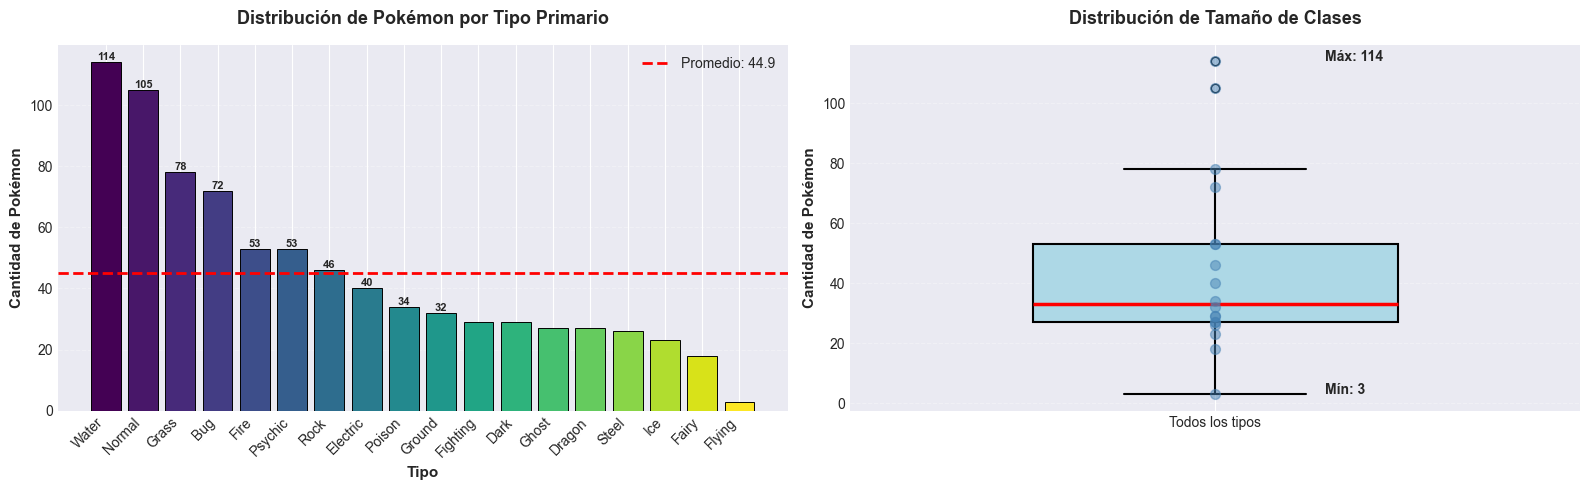


Desbalance de clases (Máx/Mín): 38.00x


In [54]:
type1_counts = df_with_images['Type1'].value_counts()
type1_counts = type1_counts.sort_values(ascending=False)

most_frequent = type1_counts.index[0]
least_frequent = type1_counts.index[-1]

print(f"DISTRIBUCIÓN DE TIPOS DE POKÉMON")
print(f"Total de tipos únicos: {len(type1_counts)}")
print(f"\nTipo más frecuente: {most_frequent} ({type1_counts.iloc[0]} Pokémon)")
print(f"Tipo menos frecuente: {least_frequent} ({type1_counts.iloc[-1]} Pokémon)")
print(f"\nTop 10 tipos más frecuentes:")
print(type1_counts.head(10).to_string())

stats = {
    'Mínimo': type1_counts.min(),
    'Máximo': type1_counts.max(),
    'Promedio': type1_counts.mean(),
    'Mediana': type1_counts.median(),
    'Desv. Estándar': type1_counts.std()
}

print(f"\nEstadísticas: Min={stats['Mínimo']:.0f}, Máx={stats['Máximo']:.0f}, Prom={stats['Promedio']:.1f}, Med={stats['Mediana']:.0f}, Desv={stats['Desv. Estándar']:.1f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors = plt.cm.viridis(np.linspace(0, 1, len(type1_counts)))
bars = axes[0].bar(range(len(type1_counts)), type1_counts.values, color=colors, edgecolor='black', linewidth=0.7)
axes[0].set_xticks(range(len(type1_counts)))
axes[0].set_xticklabels(type1_counts.index, rotation=45, ha='right', fontsize=10)
axes[0].set_title('Distribución de Pokémon por Tipo Primario', fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel('Tipo', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Cantidad de Pokémon', fontsize=11, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].axhline(y=stats['Promedio'], color='red', linestyle='--', linewidth=2, label=f"Promedio: {stats['Promedio']:.1f}")
axes[0].legend(fontsize=10)

for bar in bars[:10]:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontsize=8, fontweight='bold')

bp = axes[1].boxplot(type1_counts.values, vert=True, patch_artist=True, widths=0.5,
                      boxprops=dict(facecolor='lightblue', edgecolor='black', linewidth=1.5),
                      medianprops=dict(color='red', linewidth=2.5),
                      whiskerprops=dict(linewidth=1.5),
                      capprops=dict(linewidth=1.5))
axes[1].scatter([1]*len(type1_counts), type1_counts.values, alpha=0.5, s=50, color='steelblue', zorder=3)
axes[1].set_title('Distribución de Tamaño de Clases', fontsize=13, fontweight='bold', pad=15)
axes[1].set_ylabel('Cantidad de Pokémon', fontsize=11, fontweight='bold')
axes[1].set_xticklabels(['Todos los tipos'])
axes[1].grid(axis='y', alpha=0.3, linestyle='--')
axes[1].text(1.15, stats['Máximo'], f"Máx: {stats['Máximo']:.0f}", fontsize=10, fontweight='bold')
axes[1].text(1.15, stats['Mínimo'], f"Mín: {stats['Mínimo']:.0f}", fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

imbalance_ratio = type1_counts.max() / type1_counts.min()
print(f"\nDesbalance de clases (Máx/Mín): {imbalance_ratio:.2f}x")

## 1.4 Dimensiones y canales de las imágenes

ANÁLISIS DE PROPIEDADES DE IMÁGENES

Dimensiones de imagen (muestra de 100 imágenes):
  Resolución: UNIFORME 120×120 píxeles

Formato de color:
  RGBA: 100 imágenes (100.0%)

Canales por imagen:
  4 canales: 100 imágenes (100.0%)

Conclusion: Todas las imágenes son RGBA con 4 canales (RGB + transparencia Alpha)


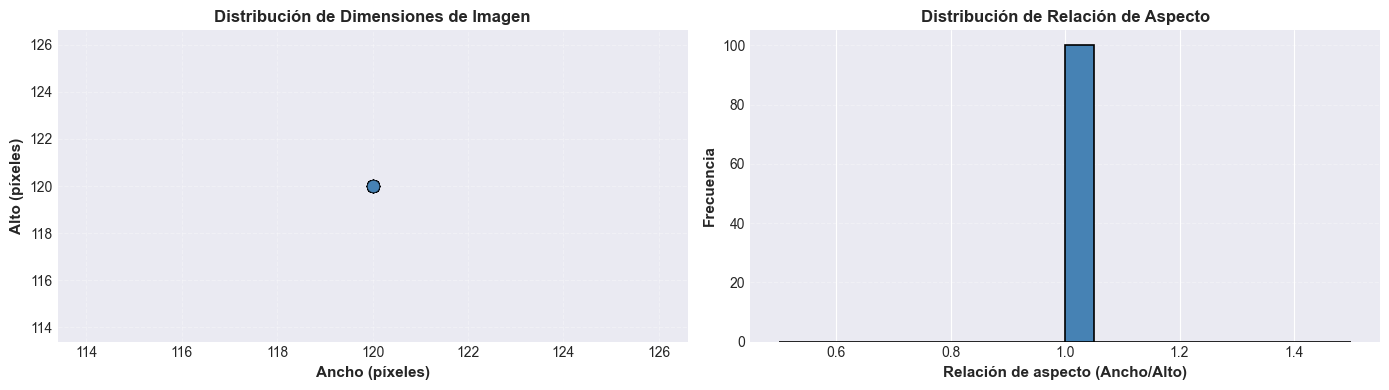


Relación de aspecto: Mín=1.00, Máx=1.00, Prom=1.00


In [55]:
print("ANÁLISIS DE PROPIEDADES DE IMÁGENES")

image_properties = []
sample_size = min(100, len(df_with_images))

for idx, row in df_with_images.head(sample_size).iterrows():
    pokemon_name = row['pokemon_lower']
    img_path = os.path.join(images_dir, f'{pokemon_name}.png')
    
    try:
        img = Image.open(img_path)
        image_properties.append({
            'name': pokemon_name,
            'width': img.width,
            'height': img.height,
            'mode': img.mode,
            'channels': len(img.getbands())
        })
    except Exception as e:
        print(f"Error al cargar {pokemon_name}: {e}")

img_props_df = pd.DataFrame(image_properties)

width_unique = img_props_df['width'].unique()
height_unique = img_props_df['height'].unique()

print(f"\nDimensiones de imagen (muestra de {len(img_props_df)} imágenes):")
if len(width_unique) == 1:
    print(f"  Resolución: UNIFORME {int(width_unique[0])}×{int(height_unique[0])} píxeles")
else:
    print(f"  Ancho: Mín={img_props_df['width'].min()}, Máx={img_props_df['width'].max()}, Prom={img_props_df['width'].mean():.0f}")
    print(f"  Alto: Mín={img_props_df['height'].min()}, Máx={img_props_df['height'].max()}, Prom={img_props_df['height'].mean():.0f}")

print(f"\nFormato de color:")
for mode, count in img_props_df['mode'].value_counts().items():
    pct = (count / len(img_props_df)) * 100
    print(f"  {mode}: {count} imágenes ({pct:.1f}%)")

print(f"\nCanales por imagen:")
for ch, count in img_props_df['channels'].value_counts().items():
    pct = (count / len(img_props_df)) * 100
    print(f"  {ch} canales: {count} imágenes ({pct:.1f}%)")

print(f"\nConclusion: Todas las imágenes son RGBA con 4 canales (RGB + transparencia Alpha)")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].scatter(img_props_df['width'], img_props_df['height'], alpha=0.6, s=80, color='steelblue', edgecolors='black', linewidth=0.5)
axes[0].set_xlabel('Ancho (píxeles)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Alto (píxeles)', fontsize=11, fontweight='bold')
axes[0].set_title('Distribución de Dimensiones de Imagen', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3, linestyle='--')

img_props_df['aspect_ratio'] = img_props_df['width'] / img_props_df['height']
axes[1].hist(img_props_df['aspect_ratio'], bins=20, color='steelblue', edgecolor='black', linewidth=1.2)
axes[1].set_xlabel('Relación de aspecto (Ancho/Alto)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Frecuencia', fontsize=11, fontweight='bold')
axes[1].set_title('Distribución de Relación de Aspecto', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

aspect_stats = img_props_df['aspect_ratio'].describe()
print(f"\nRelación de aspecto: Mín={aspect_stats['min']:.2f}, Máx={aspect_stats['max']:.2f}, Prom={aspect_stats['mean']:.2f}")

## 1.5 Muestras visuales por tipo de Pokémon

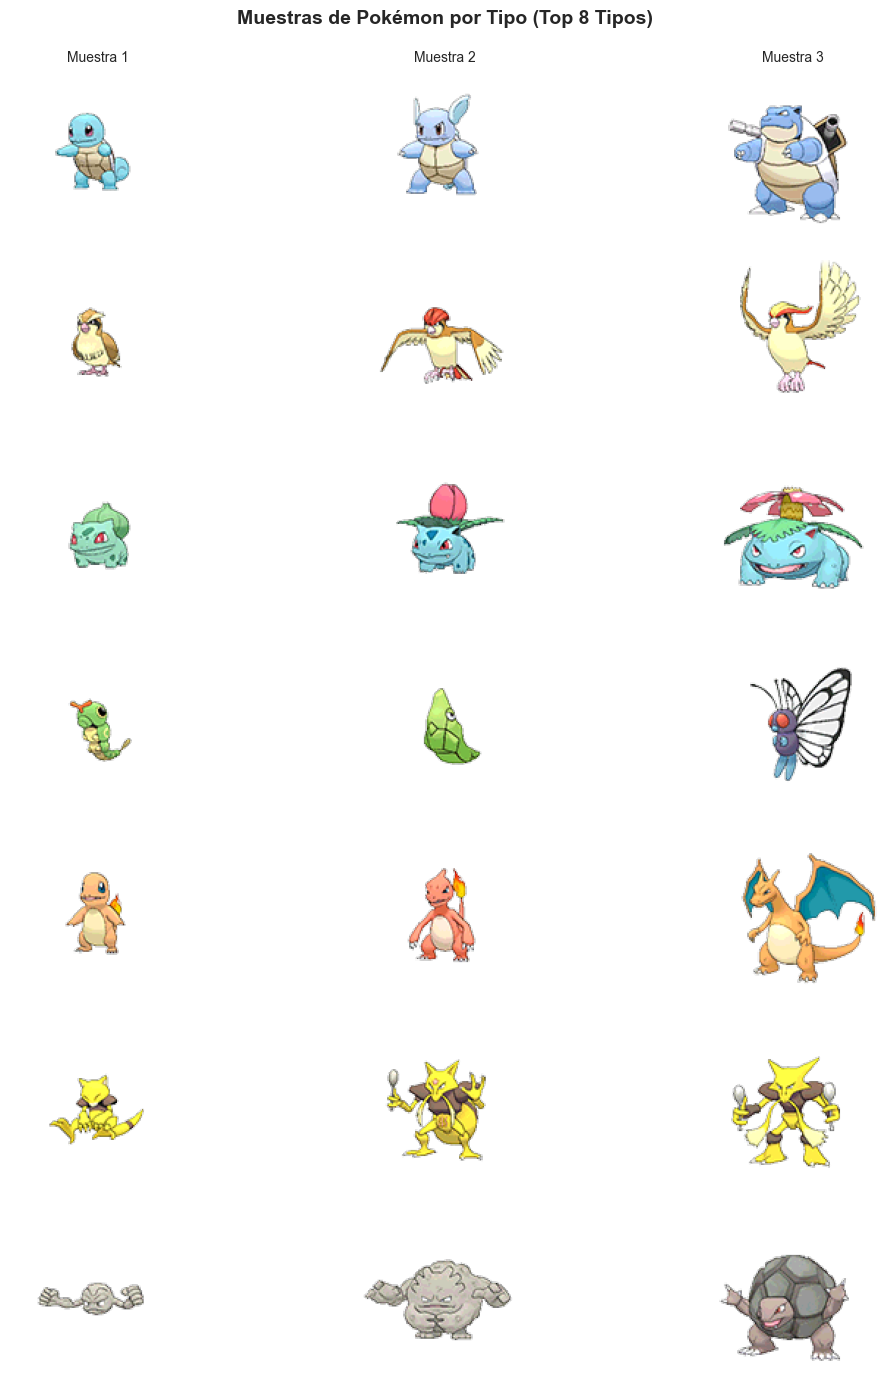

In [56]:
types_to_show = type1_counts.head(7).index.tolist()
samples_per_type = 3

fig, axes = plt.subplots(len(types_to_show), samples_per_type, figsize=(12, 14))

for type_idx, pokemon_type in enumerate(types_to_show):
    type_samples = df_with_images[df_with_images['Type1'] == pokemon_type].head(samples_per_type)
    
    for sample_idx, (_, row) in enumerate(type_samples.iterrows()):
        pokemon_name = row['pokemon_lower']
        img_path = os.path.join(images_dir, f'{pokemon_name}.png')
        
        try:
            img = Image.open(img_path)
            axes[type_idx, sample_idx].imshow(img)
            axes[type_idx, sample_idx].axis('off')
            
            if sample_idx == 0:
                axes[type_idx, sample_idx].set_ylabel(pokemon_type, fontsize=11, fontweight='bold', labelpad=10)
            
            if type_idx == 0:
                axes[type_idx, sample_idx].set_title(f'Muestra {sample_idx + 1}', fontsize=10)
                
        except Exception as e:
            axes[type_idx, sample_idx].text(0.5, 0.5, f'Error al cargar\n{pokemon_name}', 
                                             ha='center', va='center')
            axes[type_idx, sample_idx].axis('off')

plt.suptitle('Muestras de Pokémon por Tipo (Top 8 Tipos)', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

## 1.6 Preprocesamiento


ANÁLISIS DE PREPROCESAMIENTO

Estadísticas de valores de píxel (muestra de 10 imágenes):
  Mínimo: 0
  Máximo: 255
  Promedio: 27.31
  Desviación estándar: 66.35


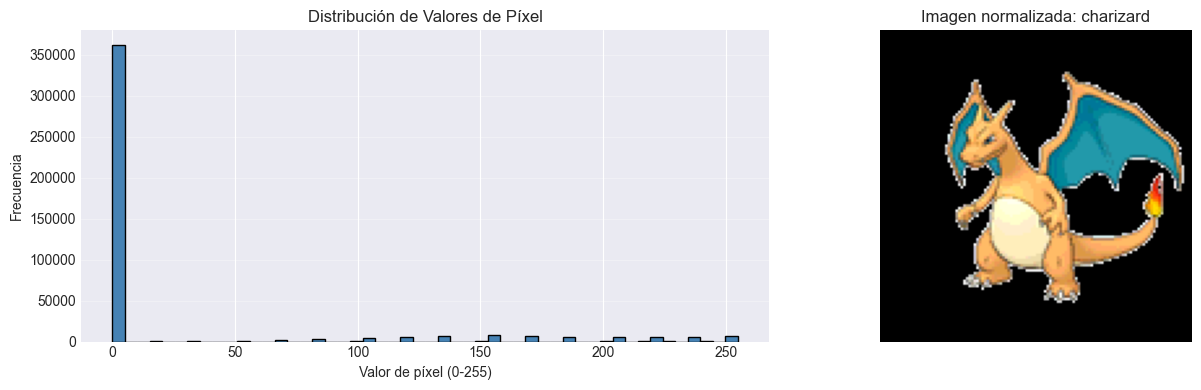

In [57]:
print("\n" + "=" * 60)
print("ANÁLISIS DE PREPROCESAMIENTO")
print("=" * 60)

pixel_values = []
sample_images = 10

for idx, row in df_with_images.head(sample_images).iterrows():
    pokemon_name = row['pokemon_lower']
    img_path = os.path.join(images_dir, f'{pokemon_name}.png')
    
    try:
        img = Image.open(img_path)
        if img.mode != 'RGB':
            img = img.convert('RGB')
        
        img_array = np.array(img)
        pixel_values.extend(img_array.flatten())
    except:
        pass

pixel_values = np.array(pixel_values)

print(f"\nEstadísticas de valores de píxel (muestra de {sample_images} imágenes):")
print(f"  Mínimo: {pixel_values.min()}")
print(f"  Máximo: {pixel_values.max()}")
print(f"  Promedio: {pixel_values.mean():.2f}")
print(f"  Desviación estándar: {pixel_values.std():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(pixel_values, bins=50, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Valor de píxel (0-255)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de Valores de Píxel')
axes[0].grid(axis='y', alpha=0.3)

sample_idx = 5
pokemon_name = df_with_images.iloc[sample_idx]['pokemon_lower']
img_path = os.path.join(images_dir, f'{pokemon_name}.png')
sample_img = Image.open(img_path)

if sample_img.mode != 'RGB':
    sample_img = sample_img.convert('RGB')

sample_array = np.array(sample_img).astype(float)
normalized_array = sample_array / 255.0

axes[1].imshow(normalized_array.astype(np.uint8) if normalized_array.max() > 1 else (normalized_array * 255).astype(np.uint8))
axes[1].set_title(f'Imagen normalizada: {pokemon_name}')
axes[1].axis('off')

plt.tight_layout()
plt.show()
